In [1]:
# Standard library imports
import os
import sys
import random
import warnings
import math

# Third-party numerical and data handling
import numpy as np
import pandas as pd
import h5py
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
from tqdm import tqdm

# Machine learning utilities
from sklearn.metrics import (
    average_precision_score,
    label_ranking_average_precision_score,
    roc_auc_score,
    brier_score_loss,
    f1_score
)

# PyTorch core
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torch.amp import autocast, GradScaler

# PyTorch vision
from torchvision import models

# Albumentations
import albumentations as A
from albumentations.core.transforms_interface import ImageOnlyTransform
from albumentations.pytorch import ToTensorV2

# Custom modules (Kaggle inputs)
# sys.path.append("/kaggle/input/asymmetric-loss-dataset")
# sys.path.append("/kaggle/input/data-preprocessing")
# sys.path.append("/kaggle/input/data-transformations")

from losses import AsymmetricLossOptimized
from preprocess import ecg_processing_pipeline, smart_pad_and_resize_ecg
from transformations import CornerCutout, GradientShadow, PaperFoldEffect, BottomBlur

In [2]:
def check_device():
    """
    Check available compute devices and return the best one.
    Priority: CUDA > MPS > CPU
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("✓ CUDA available")
        print(f"  GPU: {torch.cuda.get_device_name(0)}")
        print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("✓ MPS (Apple Silicon GPU) available")
    else:
        device = torch.device("cpu")
        print("✗ Using CPU (no GPU acceleration available)")
    
    print(f"\nSelected device: {device}")
    return device

# Check and get device
device = check_device()

✓ MPS (Apple Silicon GPU) available

Selected device: mps


In [3]:
model = "ConvNext"

In [4]:
class Head(nn.Module):
    def __init__(self, in_features, hidden_layer, dropout_rate=0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, hidden_layer),
            nn.BatchNorm1d(hidden_layer),  
            nn.GELU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_layer, hidden_layer // 2), 
            nn.BatchNorm1d(hidden_layer // 2),
            nn.GELU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_layer // 2, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

if model == "EfficientNet":
    class MultiHeadEfficientNet(nn.Module):
        def __init__(self, num_conditions=5, hidden_dim=512, dropout_rate=0.3):
            super().__init__()
            
            backbone = models.efficientnet_v2_s(weights="DEFAULT")
            in_features = backbone.classifier[1].in_features
            backbone.classifier = nn.Identity()
            
            self.backbone = backbone
            
            self.shared_feature_processor = nn.Sequential(
                nn.Linear(in_features, in_features), 
                nn.BatchNorm1d(in_features),
                nn.GELU(), 
                nn.Dropout(p=dropout_rate),
                nn.Linear(in_features, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.GELU(),
                nn.Dropout(p=dropout_rate)
            )
            
            self.heads = nn.ModuleList([
                Head(hidden_dim, hidden_dim // 2, dropout_rate) 
                for _ in range(num_conditions)
            ])
            
        def forward(self, x):
            backbone_feats = self.backbone(x)
            processed_feats = self.shared_feature_processor(backbone_feats)
            outputs = [head(processed_feats) for head in self.heads]
            return torch.cat(outputs, dim=1)  # [batch, num_conditions]
elif model == "ConvNext": 

    class MultiHeadEfficientNet(nn.Module):
        def __init__(self, num_conditions=5, hidden_dim=512, dropout_rate=0.3):
            super().__init__()
            
            backbone = models.convnext_base(weights="IMAGENET1K_V1", progress=True)
            in_features = backbone.classifier[2].in_features
            assert isinstance(in_features, int), f"in_features should be int, got {type(in_features)}"
            
            backbone.classifier = nn.Identity()
            self.backbone = backbone
            
            self.shared_feature_processor = nn.Sequential(
                nn.Linear(in_features, in_features), 
                nn.BatchNorm1d(in_features),
                nn.GELU(), 
                nn.Dropout(p=dropout_rate),
                nn.Linear(in_features, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.GELU(),
                nn.Dropout(p=dropout_rate)
            )
            
            self.heads = nn.ModuleList([
                Head(hidden_dim, hidden_dim // 2, dropout_rate) 
                for _ in range(num_conditions)
            ])
            
        def forward(self, x):
            backbone_feats = self.backbone(x).flatten(1) # squeeze non-batch dimension
            processed_feats = self.shared_feature_processor(backbone_feats)
            outputs = [head(processed_feats) for head in self.heads]
            return torch.cat(outputs, dim=1)  # [batch, num_conditions]
        
else: 
    
    raise Exception("Model not recognised")

In [4]:
def load_contours_from_hdf5(filepath='/kaggle/input/ecg-image-contours/contours.h5'):
    """
    Load all contours from HDF5 file back into dictionary format
    """
    contour_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for img_id in f.keys():
            grp = f[img_id]
            
            contour_dict[img_id] = {
                'contour': grp['contour'][:],  # Load the contour array
                'scale_x': grp.attrs['scale_x'],
                'scale_y': grp.attrs['scale_y'], 
                'half': grp.attrs['half']
            }
    
    return contour_dict

# Usage
try: 
    print(contours["train_000000"])
except Exception as e: 
    contours = load_contours_from_hdf5(filepath="/Users/griffin/Documents/Data_Science_Projects/bhf_classification/seg_model/image_preprocessing/contours.h5")

In [5]:
def process_single_img(
                img,
                img_id,
                desired_aspect=0.5,
                target_width=512
                ):
    value = f"train_{str(img_id).zfill(6)}.png"
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    output = ecg_processing_pipeline(input_image = img, 
                                contour_data = contours[value.split(".")[0]])
    resize_output = smart_pad_and_resize_ecg(output, target_size=(int(target_width*desired_aspect), 512), resize_strategy=cv2.INTER_AREA)
    return resize_output

def imread_clean(path):
    img = Image.open(path)
    img = img.convert('RGB')  # Strips metadata
    return np.array(img)

class ECGDataset(Dataset): 
    def __init__(self,
                image_paths, 
                labels_df, 
                transforms=None):
        
        self.image_paths = image_paths
        self.labels_dict = {idx: torch.tensor(row.values, dtype=torch.float32) 
                            for idx, row in labels_df.iterrows()}
        
        self.idx_to_image_id = {}
        for idx, path in enumerate(self.image_paths):
            filename = os.path.basename(path)
            image_id = int(filename.rsplit('_', 1)[-1].split('.')[0])
            self.idx_to_image_id[idx] = image_id
        
        self.transforms = transforms
        
    def __len__(self): 
        return len(self.image_paths)
        
    def __getitem__(self, idx): 
        image_path = self.image_paths[idx]
        index = self.idx_to_image_id[idx]
        label = self.labels_dict[index]
        image = imread_clean(image_path)
        if image is None:
            raise ValueError(f"Failed to load image: {image_path}")
        # convert image using our segmentation pipeline 
        image_conv = process_single_img(
            img=image, 
            img_id=index,
            desired_aspect=0.5, 
            target_width=512
        )
        image_conv = np.stack([image_conv, image_conv, image_conv], axis=-1)
        if self.transforms is not None: 
            image_tens = self.transforms(image=image_conv)["image"]
        else: 
            image_tens = image_conv
        return image_tens, label

In [6]:
val_transforms = A.Compose([
    A.CLAHE(
        clip_limit=4,
        tile_grid_size=(8, 8),
        p=1.0
    ),
    # Normalization (ImageNet)
    A.Normalize(mean=[0.485, 0.456, 0.406], 
                std=[0.229, 0.224, 0.225]),
    # Convert to tensor
    ToTensorV2()
])

In [7]:
from sklearn.model_selection import train_test_split

labels_df = pd.read_csv("/Users/griffin/Documents/Data_Science_Projects/bhf_classification/data/train_final.csv", index_col=0, dtype=int)

with open("/Users/griffin/Documents/Data_Science_Projects/bhf_classification/broken_images/broken_images_list.txt", "r") as file:
    broken_train_images = [line.strip() for line in file]
with open("/Users/griffin/Documents/Data_Science_Projects/bhf_classification/broken_images/broken_test_images_list.txt", "r") as file:
    broken_test_images = [line.strip() for line in file]
with open("/Users/griffin/Documents/Data_Science_Projects/bhf_classification/broken_images/valid_images_list.txt", "r") as file:
    valid_train_images = [line.strip() for line in file]
with open("/Users/griffin/Documents/Data_Science_Projects/bhf_classification/broken_images/valid_test_images_list.txt", "r") as file:
    valid_test_images = [line.strip() for line in file]

all_ids = set([int(obj.split(".")[-2][-6:]) for obj in valid_train_images])

labels_df = labels_df.loc[labels_df.index.isin(all_ids)]

# split train set, using stratification 
X_train, X_test, y_train, y_test = train_test_split(valid_train_images, 
                                                    labels_df, 
                                                    test_size = 0.2,
                                                    random_state = 42, 
                                                    shuffle = True, 
                                                    stratify = labels_df[["CD", "MI", "AF", "STTC", "HYP"]])

In [8]:
# identify which of these images we actually have locally
import glob 
local_files = glob.glob(os.path.abspath(os.path.join("../", "data", "train", "train_*")))
indices = set([int(item.split(".")[0][-6:]) for item in local_files])

# usable local ids 
local_ids = indices.intersection(all_ids)

# downsample ids to be more tractable numbers
#local_ids = [id_val for ind, id_val in enumerate(local_ids) if ind%10 == 0]

# filter X_train and X_test to only contain the correct ids
X_train_usable = [elem for elem in X_train if int(elem.split(".")[0][-6:]) in local_ids]
X_test_usable = [elem for elem in X_test if int(elem.split(".")[0][-6:]) in local_ids]

# rewrite paths to actually be the local ones
X_train = [os.path.abspath(os.path.join("../", "data", "train", path.split("/")[-1])) for path in X_train_usable]
X_test = [os.path.abspath(os.path.join("../", "data", "train", path.split("/")[-1])) for path in X_test_usable]

In [9]:
num_workers = 0 if sys.platform == 'darwin' else 4 
print(f"Using num_workers = {num_workers}")

# train_dataset = ECGDataset(
#                     image_paths=X_train, 
#                     labels_df=labels_df, 
#                     transforms=train_transforms, 
#                     )
val_dataset = ECGDataset(
                    image_paths=X_test, 
                    labels_df=labels_df, 
                    transforms=val_transforms, 
                    ) 

# train_dataloader = DataLoader( 
#                         train_dataset,
#                         batch_size=8, 
#                         shuffle=True, 
#                         num_workers=num_workers, 
#                         pin_memory=True if device.type == "cuda" else False)
val_dataloader = DataLoader( 
                        val_dataset,
                        batch_size=8, 
                        shuffle=False, 
                        num_workers=num_workers, 
                        pin_memory=True if device.type == "cuda" else False)

Using num_workers = 0


In [10]:
def compute_ranking_metrics(all_y_true, all_y_pred):
    """
    Compute AP/AUROC/LRAP ranking metrics. Inputs are numpy arrays.
    """
    L = all_y_true.shape[1]

    per_label_ap = []
    per_label_auroc = []
    per_label_brier = []
    per_label_brier_baseline = []
    thresholds = []
    per_label_f1s = []
    
    for j in range(L):
        
        y_true = all_y_true[:, j]
        y_pred = all_y_pred[:, j]

        # ---- Check label validity once ----
        unique_classes = np.unique(y_true)
        has_both_classes = (len(unique_classes) == 2)
        has_any_positive = (np.sum(y_true) > 0)

        # ----- Average Precision -----
        if has_any_positive:
            ap = average_precision_score(y_true, y_pred)
        else:
            ap = float('nan') 
        per_label_ap.append(float(ap))

        # ----- AUROC -----
        if has_both_classes:
            auroc = roc_auc_score(y_true, y_pred)
        else:
            auroc = float('nan')
        per_label_auroc.append(float(auroc))

        # Brier
        br = brier_score_loss(all_y_true[:, j], all_y_pred[:, j])
        per_label_brier.append(float(br))
        p = np.mean(y_true)  # class prevalence
        brier_baseline = p * (1 - p)
        per_label_brier_baseline.append(float(brier_baseline))
        
        # F1 score
        best_f1 = 0
        best_t = 0.5
        for t in np.linspace(0.01, 0.99, 99):
            f1 = f1_score(y_true, (y_pred >= t).astype(int))
            if f1 > best_f1: 
                best_f1 = f1 
                best_t = t 
        best_t = round(float(best_t), 2)
        thresholds.append(best_t)
        per_label_f1s.append(best_f1)
        
    relative_brier_improvement = [
        (per_label_brier_baseline[ind] - per_label_brier[ind]) / per_label_brier_baseline[ind]
        if per_label_brier_baseline[ind] > 0 else float('nan')
        for ind in range(L)
    ]
    # Micro-averaged metrics
    try:
        micro_ap = average_precision_score(all_y_true.reshape(-1), all_y_pred.reshape(-1))
    except ValueError:
        micro_ap = float('nan')
    try:
        micro_auroc = roc_auc_score(all_y_true.reshape(-1), all_y_pred.reshape(-1))
    except ValueError:
        micro_auroc = float('nan')
    
    # Macro-averaged metrics
    macro_ap = float(np.nanmean(per_label_ap))
    macro_auroc = float(np.nanmean(per_label_auroc))
    macro_brier = float(np.mean(per_label_brier))
    macro_f1 = float(np.mean(per_label_f1s))
    
    # LRAP
    lrap = label_ranking_average_precision_score(all_y_true, all_y_pred)

    return {
        "per_label_ap": per_label_ap,
        "per_label_auroc": per_label_auroc,
        "per_label_brier": per_label_brier,
        "per_label_brier_baseline": per_label_brier_baseline,
        "relative_brier_improvement": relative_brier_improvement,
        "per_label_f1": per_label_f1s, 
        "thresholds": thresholds,
        "macro_ap": float(macro_ap),
        "macro_auroc": float(macro_auroc),
        "macro_brier": float(macro_brier),
        "macro_f1": float(macro_f1),
        "micro_ap": float(micro_ap),
        "micro_auroc": float(micro_auroc),
        "lrap": float(lrap),
    }


In [11]:
checkpoint_path = "weak_asymm_checkpoint.pth"
try: 
    checkpoint = torch.load(checkpoint_path, map_location=torch.device("cpu"), weights_only=False)
    current_epoch = checkpoint["epoch"]
    print(f"Loading from checkpoint, last run epoch was {current_epoch}")
except Exception as e: 
    print("*"*50)
    print("No checkpoint found, unable to proceed with model evaluation")
    print("*"*50)
    raise Exception(f"{e}")

Loading from checkpoint, last run epoch was 11


In [12]:
model = MultiHeadEfficientNet(
    num_conditions=5, 
    hidden_dim=512, 
    dropout_rate=0.3
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [13]:
val_ranking_stats = []
model.eval()
pbar = tqdm(total=len(val_dataloader),
            desc=f"Epoch {current_epoch} - Validation", 
            unit="batch")
total_samples = 0
val_y_true_list = []
val_y_pred_list = []
with torch.inference_mode(): 
    for i, (inputs, labels) in enumerate(val_dataloader): 
        if (i + 1) % 10 == 0 or (i + 1) == len(val_dataloader):
            pbar.n = i + 1
            pbar.refresh()

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        if device.type == "cuda": 
            with autocast('cuda'): 
                outputs = model(inputs)
        else:
            outputs = model(inputs)
            
        y_pred = torch.sigmoid(outputs)
        val_y_pred_list.append(y_pred.cpu())
        val_y_true_list.append(labels.cpu())
        
pbar.close()

all_y_true = torch.cat(val_y_true_list).numpy()
all_y_pred = torch.cat(val_y_pred_list).numpy()

Epoch 11 - Validation: 100%|██████████| 199/199 [03:55<00:00,  1.18s/batch]


In [14]:
ranking_metrics = compute_ranking_metrics(all_y_true, all_y_pred)

In [15]:
import json 
with open("weak_asymm_model_metrics.json", "w") as file:
    json.dump(ranking_metrics, file)

In [16]:
with open("asymm_model_metrics.json", "r") as file: 
    asymm_model_metrics = json.load(file)
    
with open("bce_model_metrics.json", "r") as file: 
    bce_model_metrics = json.load(file)

In [17]:
from tabulate import tabulate

def summarize_metrics(metrics):
    
    table = [
        ["Macro AP", metrics["macro_ap"]],
        ["Macro AUROC", metrics["macro_auroc"]],
        ["Macro Brier", metrics["macro_brier"]],
        ["Macro F1", metrics["macro_f1"]],
        ["Micro AP", metrics["micro_ap"]],
        ["Micro AUROC", metrics["micro_auroc"]],
        ["LRAP", metrics["lrap"]]
    ]
    
    print(tabulate(table, headers=["Metric", "Value"], floatfmt=".4f"))

print("="*10)
print("Asymm")
print("="*10)
summarize_metrics(asymm_model_metrics)
print()
print("="*10)
print("BCE")
print("="*10)
summarize_metrics(bce_model_metrics)
print()
print("="*10)
print("Weak Asymm")
print("="*10)
summarize_metrics(ranking_metrics)

Asymm
Metric         Value
-----------  -------
Macro AP      0.7818
Macro AUROC   0.9224
Macro Brier   0.1081
Macro F1      0.7172
Micro AP      0.7901
Micro AUROC   0.9287
LRAP          0.9396

BCE
Metric         Value
-----------  -------
Macro AP      0.7807
Macro AUROC   0.9252
Macro Brier   0.0824
Macro F1      0.7348
Micro AP      0.7748
Micro AUROC   0.9312
LRAP          0.9400

Weak Asymm
Metric         Value
-----------  -------
Macro AP      0.6821
Macro AUROC   0.8857
Macro Brier   0.1379
Macro F1      0.6518
Micro AP      0.6946
Micro AUROC   0.8928
LRAP          0.9094


In [18]:
def per_label_table(metrics):
    rows = []
    L = len(metrics["per_label_ap"])

    for j in range(L):
        rows.append([
            j,
            metrics["per_label_ap"][j],
            metrics["per_label_auroc"][j],
            metrics["per_label_brier"][j],
            metrics["per_label_brier_baseline"][j],
            metrics["relative_brier_improvement"][j],
            metrics["per_label_f1"][j],
            metrics["thresholds"][j]
        ])
    
    print(tabulate(
        rows,
        headers=[
            "Label",
            "AP",
            "AUROC",
            "Brier",
            "Brier Baseline",
            "Rel Brier Imp",
            "F1",
            "Thresh"
        ],
        floatfmt=".4f",
        tablefmt="pretty"
    ))

print("="*10)
print("Asymm")
print("="*10)
per_label_table(asymm_model_metrics)
print()
print("="*10)
print("BCE")
print("="*10)
per_label_table(bce_model_metrics)
print()
print("="*10)
print("Weak Asymm")
print("="*10)
per_label_table(ranking_metrics)

Asymm
+-------+--------------------+--------------------+---------------------+---------------------+----------------------+--------------------+--------+
| Label |         AP         |       AUROC        |        Brier        |   Brier Baseline    |    Rel Brier Imp     |         F1         | Thresh |
+-------+--------------------+--------------------+---------------------+---------------------+----------------------+--------------------+--------+
|   0   | 0.7635888234037221 | 0.911353544819416  | 0.14327799193094173 | 0.17987187206745148 | 0.20344415008249392  | 0.7008086253369272 |  0.62  |
|   1   | 0.6331972577450133 | 0.883571114201029  | 0.11284079095354933 | 0.10207100212574005 | -0.10551271765258176 | 0.5859154929577465 |  0.56  |
|   2   | 0.8188326404754119 | 0.9120354239256678 | 0.12378502984408403 | 0.19168353080749512 |  0.3542218816472059  | 0.7404580152671756 |  0.55  |
|   3   | 0.8313332983741711 | 0.9225986222554762 | 0.11664872814519286 | 0.16949577629566193 |  0.3

## Investigate poorly performing labels more closely

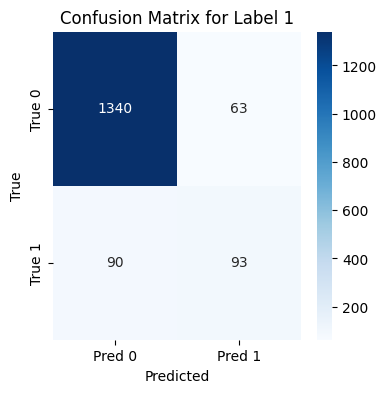

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

label_index = 1

y_true = all_y_true[:, label_index]
y_pred_prob = all_y_pred[:, label_index]
threshold = ranking_metrics["thresholds"][label_index]

# Convert probabilities to 0/1 predictions
y_pred = (y_pred_prob >= threshold).astype(int)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)

plt.title(f"Confusion Matrix for Label {label_index}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [20]:
print("Prevalence = ", labels_df.iloc[:,label_index].mean())

Prevalence =  0.12326759061833689


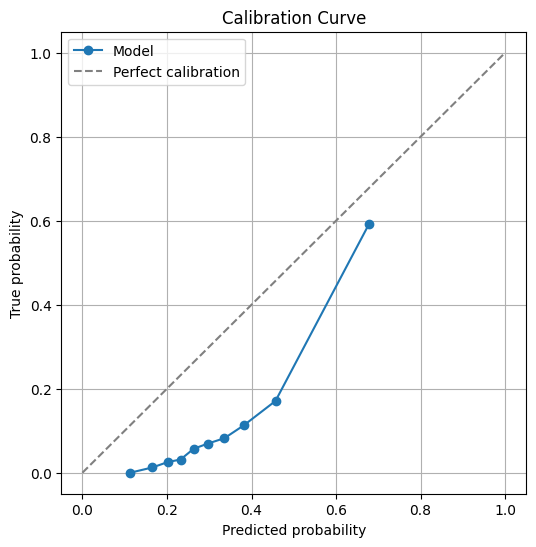

In [21]:
from sklearn.calibration import calibration_curve

y_true = all_y_true[:,label_index]
y_pred = all_y_pred[:,label_index]

prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=10, strategy="quantile")
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')

plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()